# Laboratory 2: Computer Vision
## Part 1: MNIST Digit Classification

My working copy of Part 1 of the computer vision lab. The task is handwriting: take handwritten digits and classify them 0–9, using MNIST — 60,000 training images and 10,000 test images. The code is the course's; the notes in the margins are my own.

Plumbing first: pull in the packages, install the course repo, then check I'm actually on a GPU before burning an afternoon on a runtime that was never going to finish.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchsummary import summary

# MIT introduction to deep learning package
!pip install mitdeeplearning --quiet
import mitdeeplearning as mdl

import matplotlib.pyplot as plt
import numpy as np
import random
from tqdm import tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 52.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.6/158.6 kB 16.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.9/23.9 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 476.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.1/668.1 kB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.7/99.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.0/345.0 kB 34.9 MB/s eta 0:00:00
   ━━━━

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
!pip install comet_ml
import comet_ml
# TODO: ENTER YOUR API KEY HERE!!
COMET_API_KEY = "ndyBfjKBvjr8FsGttvDzoo79o"

# Check that we are using a GPU, if not switch runtimes
#   using Runtime > Change Runtime Type > GPU
assert torch.cuda.is_available(), "Please enable GPU from runtime settings"
assert COMET_API_KEY != "", "Please insert your Comet API Key"

# Set GPU for computation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.7/829.7 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.7 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.4.1
    Uninstalling python-box-7.4.1:
      Successfully uninstalled python-box-7.4.1


/usr/local/lib/python3.13/dist-packages/comet_ml/error_tracking/shutdown.py:22: SentryHubDeprecationWarning: `sentry_sdk.Hub` is deprecated and will be removed in a future major release. Please consult our 1.x to 2.x migration guide for details on how to migrate `Hub` usage to the new API: https://docs.sentry.io/platforms/python/migration/1.x-to-2.x
  client = sentry_sdk.Hub.current.client
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
# start a first comet experiment for the first part of the lab
comet_ml.init(project_name="6S191_lab2_part1_NN")
comet_model_1 = comet_ml.Experiment()

COMET WARNING: comet_ml.init() is deprecated and will be removed soon. Please use comet_ml.login()


Please paste your Comet API key from https://www.comet.com/api/my/settings/
(api key may not show as you type)
Comet API key: ··········


COMET INFO: Valid Comet API Key saved in /root/.comet.config (set COMET_CONFIG to change where it is saved).
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch, keras, tensorflow, sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/somil-singh/6s191-lab2-part1-nn/6c57eb7eaacd4f54bc28481812e8a62f



### 1.1 MNIST dataset
Let's download and load the dataset and display a few random samples from it:

In [4]:
# Download and transform the MNIST dataset
transform = transforms.Compose([
    # Convert images to PyTorch tensors which also scales data from [0,255] to [0,1]
    transforms.ToTensor()
])

# Download training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
100%|██████████| 9.91M/9.91M [00:00<00:00, 15.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 457kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.9MB/s]


The MNIST dataset object in PyTorch is not a simple tensor or array. It's an iterable dataset that loads samples (image-label pairs) one at a time or in batches. In a later section of this lab, we will define a handy DataLoader to process the data in batches.

In [5]:
image, label = train_dataset[0]
print(image.size())  # For a tensor: torch.Size([1, 28, 28])
print(label)  # For a label: integer (e.g., 5)

torch.Size([1, 28, 28])
5


Our training set is made up of 28x28 grayscale images of handwritten digits.
Let's visualize what some of these images and their corresponding training labels look like.

/usr/local/lib/python3.13/dist-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  x = np.array(x, subok=True, copy=copy)


{'web': 'https://www.comet.com/api/image/download?imageId=e8518ad8aabe4702970729526ca5543b&experimentKey=6c57eb7eaacd4f54bc28481812e8a62f',
 'api': 'https://www.comet.com/api/rest/v1/image/get-image?imageId=e8518ad8aabe4702970729526ca5543b&experimentKey=6c57eb7eaacd4f54bc28481812e8a62f',
 'imageId': 'e8518ad8aabe4702970729526ca5543b'}

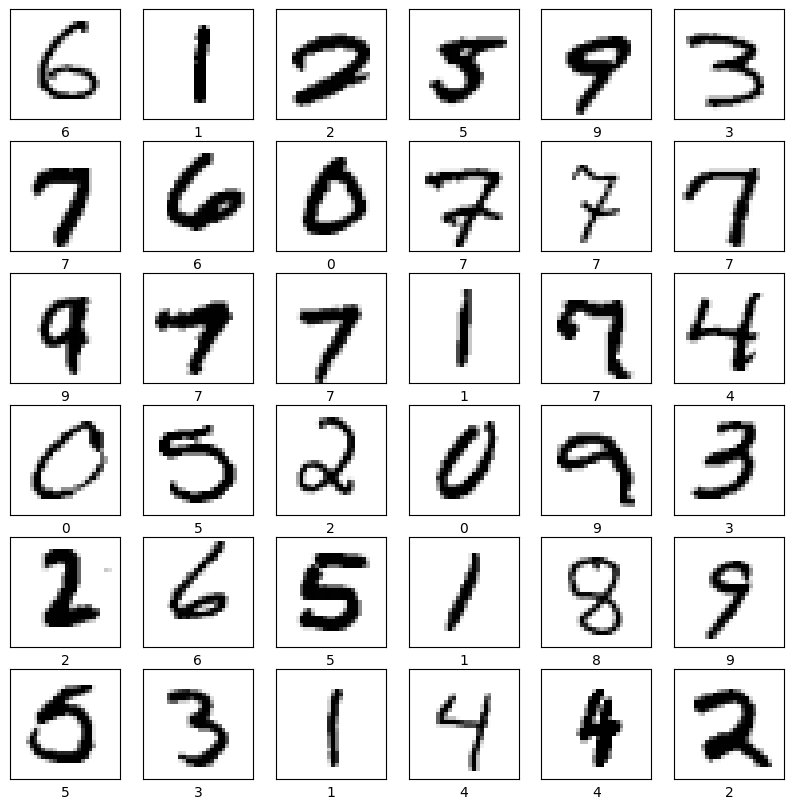

In [6]:
plt.figure(figsize=(10,10))
random_inds = np.random.choice(60000,36)
for i in range(36):
    plt.subplot(6, 6, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    image_ind = random_inds[i]
    image, label = train_dataset[image_ind]
    plt.imshow(image.squeeze(), cmap=plt.cm.binary)
    plt.xlabel(label)
comet_model_1.log_figure(figure=plt)

### 1.2 Neural Network for Handwritten Digit Classification
We'll first build a simple neural network consisting of two fully connected layers and apply this to the digit classification task. Our network will ultimately output a probability distribution over the 10 digit classes (0–9).

To define the architecture of this first fully connected neural network, we'll once again use the `torch.nn` modules, defining the model using `nn.Sequential`. Note how we first use a `nn.Flatten` layer, which flattens the input so that it can be fed into the model.
In this next block, you'll define the fully connected layers of this simple network.

In [7]:
def build_fc_model():
    fc_model = nn.Sequential(
        # First define a Flatten layer
        nn.Flatten(),

        # Activation function for the first fully connected (Dense/Linear) layer.
        nn.Linear(28 * 28, 128),
        nn.ReLU(),

        # Second Linear layer to output the classification probabilities
        nn.Linear(128, 10)
    )
    return fc_model

fc_model_sequential = build_fc_model()

📝 **My note — flatten is the part I keep meaning to rethink:**
Flattening the 28×28 image into a single vector before feeding it to the dense layers is exactly the thing convolutions were built to avoid. The neighborhood information is gone — a pixel that used to sit next to another pixel now lives as far away as any other — so the model has to relearn spatial structure (edges, curves, strokes) from scratch as if every input were an independent feature.

In [8]:
# Define the fully connected model
class FullyConnectedModel(nn.Module):
    def __init__(self):
        super(FullyConnectedModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)

        # Activation function for the first fully connected layer
        self.relu = nn.ReLU()

        # Second Linear layer to output the classification probabilities
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)

        # Rest of forward pass using the layers defined above
        x = self.relu(x)
        x = self.fc2(x)

        return x

fc_model = FullyConnectedModel().to(device) # send the model to GPU

### Model Metrics and Training Parameters
Before training the model, we need to define components that govern its performance and guide its learning process. These include the loss function, optimizer, and evaluation metrics:

* **Loss function** — This defines how we measure how accurate the model is during training. As was covered in lecture, during training we want to minimize this function, which will "steer" the model in the right direction.
* **Optimizer** — This defines how the model is updated based on the data it sees and its loss function.
* **Metrics** — Here we can define metrics that we want to use to monitor the training and testing steps. In this example, we'll define and take a look at the accuracy, the fraction of the images that are correctly classified.

We'll start out by using a stochastic gradient descent (SGD) optimizer initialized with a learning rate of 0.1. Since we are performing a categorical classification task, we'll want to use the cross entropy loss.
You'll want to experiment with both the choice of optimizer and learning rate and evaluate how these affect the accuracy of the trained model.

In [9]:
'''TODO: Experiment with different optimizers and learning rates. How do these affect
    the accuracy of the trained model? Which optimizers and/or learning rates yield
    the best performance?'''
# Define loss function and optimizer
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(fc_model.parameters(), lr=0.1)

📝 **My note — what's actually worth changing here:**
Cross entropy is fixed by the task — ten mutually exclusive classes, so logits-to-probability-to-log-loss is the right move no matter what. Where I actually have a real choice is the optimizer and learning rate. SGD with a plain learning rate is the course default and is fine for getting a first number, but Adam is usually the better starting point for these small MNIST models because it adapts per-parameter step sizes and keeps the training stable without me babysitting the learning rate. My own rule of thumb is: start with Adam at 1e-3, only drop to SGD if the loss curve looks noisy or I'm deliberately tuning for that specific setup. The interesting comparison isn't "did I beat 97%" — it's whether the curve reaches that region faster and with less hand-tuning.

### Train the model
We're now ready to train our model, which will involve feeding the training data (`train_dataset`) into the model, and then asking it to learn the associations between images and labels. We'll also need to define the batch size and the number of epochs, or iterations over the MNIST dataset, to use during training. This dataset consists of (image, label) tuples that we will iteratively access in batches.

In Lab 1, we saw how we can use the `.backward()` method to optimize losses and train models with stochastic gradient descent. In this section, we will define a function to train the model using `.backward()` and `optimizer.step()` to automatically update our model parameters (weights and biases) as we saw in Lab 1.

Recall, we mentioned in Section 1.1 that the MNIST dataset can be accessed iteratively in batches. Here, we will define a PyTorch DataLoader that will enable us to do that.

In [10]:
# Create DataLoaders for batch processing
BATCH_SIZE = 64
trainset_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
testset_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
def train(model, dataloader, criterion, optimizer, epochs):
    model.train()  # Set the model to training mode
    for epoch in range(epochs):
        total_loss = 0
        correct_pred = 0
        total_pred = 0

        for images, labels in dataloader:
            # Move tensors to GPU so compatible with model
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)

            # Clear gradients before performing backward pass
            optimizer.zero_grad()
            # Calculate loss based on model predictions
            loss = criterion(outputs, labels)
            # Backpropagate and update model parameters
            loss.backward()
            optimizer.step()

            # multiply loss by total nos. of samples in batch
            total_loss += loss.item() * images.size(0)

            # Calculate accuracy
            predicted = torch.argmax(outputs, dim=1)  # Get predicted class
            correct_pred += (predicted == labels).sum().item()  # Count correct predictions
            total_pred += labels.size(0) # Count total predictions

        # Compute metrics
        total_epoch_loss = total_loss / total_pred
        epoch_accuracy = correct_pred / total_pred
        print(f"Epoch {epoch + 1}, Loss: {total_epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

In [12]:
# Train the model by calling the function appropriately
EPOCHS = 5
train(fc_model, trainset_loader, loss_function, optimizer, EPOCHS)

comet_model_1.end()

Epoch 1, Loss: 0.4345, Accuracy: 0.8841
Epoch 2, Loss: 0.2216, Accuracy: 0.9365
Epoch 3, Loss: 0.1666, Accuracy: 0.9519
Epoch 4, Loss: 0.1346, Accuracy: 0.9613
Epoch 5, Loss: 0.1128, Accuracy: 0.9680


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : confident_belvedere_4373
COMET INFO:     url                   : https://www.comet.com/somil-singh/6s191-lab2-part1-nn/6c57eb7eaacd4f54bc28481812e8a62f
COMET INFO:   Others:
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=1xdnzT9AElOLd2Vc3q9OQSAia7OLaKowb
COMET INFO:   Uploads:
COMET INFO:     environment details : 1
COMET INFO:     figures             : 1
COMET INFO:     filename            : 1
COMET INFO:     installed packages  : 1
COMET INFO:     notebook            : 2
COMET INFO:     os packages         : 1
COMET INFO:     source_code         : 1
COMET INFO: 
COMET WARNING: To get all data logged automatically, 

As the model trains, the loss and accuracy metrics are displayed. With five epochs and a learning rate of 0.1, this fully connected model should achieve an accuracy of approximately 0.97 (or 97%) on the training data.

### Evaluate accuracy on the test dataset
Now that we've trained the model, we can ask it to make predictions about a test set that it hasn't seen before. In this example, iterating over the `testset_loader` allows us to access our test images and test labels. And to evaluate accuracy, we can check to see if the model's predictions match the labels from this loader.
Since we have now trained the model, we will use the eval state of the model on the test dataset.

In [13]:
def evaluate(model, dataloader, loss_function):
    # Evaluate model performance on the test dataset
    model.eval()
    test_loss = 0
    correct_pred = 0
    total_pred = 0
    # Disable gradient calculations when in inference mode
    with torch.no_grad():
        for images, labels in dataloader:
            # ensure evaluation happens on the GPU
            images, labels = images.to(device), labels.to(device)

            # feed the images into the model and obtain the predictions (forward pass)
            outputs = model(images)

            loss = loss_function(outputs, labels)

            # Calculate test loss
            test_loss += loss.item() * images.size(0)

            # make a prediction and determine whether it is correct!
            # identify the digit with the highest probability prediction for the images in the test dataset.
            predicted = torch.argmax(outputs, dim=1)

            # tally the number of correct predictions
            correct_pred += (predicted == labels).sum().item()

            # tally the total number of predictions
            total_pred += labels.size(0)

    # Compute average loss and accuracy
    test_loss /= total_pred
    test_acc = correct_pred / total_pred
    return test_loss, test_acc

# call the evaluate function to evaluate the trained model!!
test_loss, test_acc = evaluate(fc_model, testset_loader, loss_function)

print('Test accuracy:', test_acc)

Test accuracy: 0.9671


📝 **My note — the gap I actually saw:**
The test accuracy comes back a little lower than the training accuracy. That gap between training and test is the first real signal in this lab of why CNNs matter for images: a plain fully connected network treats every pixel as an independent feature and throws away all the spatial structure. A digit shifted a few pixels over becomes a totally different input vector to it. Convolutions fix this by sharing weights across spatial positions, which is why the next model does better on the unseen data.

You may observe that the accuracy on the test dataset is a little lower than the accuracy on the training dataset. This gap between training accuracy and test accuracy is an example of overfitting, when a machine learning model performs worse on new data than on its training data.
What is the highest accuracy you can achieve with this first fully connected model? Since the handwritten digit classification task is pretty straightforward, you may be wondering how we can do better...

### 1.3 Convolutional Neural Network (CNN) for handwritten digit classification
As we saw in lecture, convolutional neural networks (CNNs) are particularly well-suited for a variety of tasks in computer vision, and have achieved near-perfect accuracies on the MNIST dataset. We will now build a CNN composed of two convolutional layers and pooling layers, followed by two fully connected layers, and ultimately output a probability distribution over the 10 digit classes (0–9).

#### Define the CNN model
We'll use the same training and test datasets as before, and proceed similarly as our fully connected network to define and train our new CNN model. To do this we will explore two layers we have not encountered before: you can use `nn.Conv2d` to define convolutional layers and `nn.MaxPool2d` to define the pooling layers. Use the parameters shown in the network architecture above to define these layers and build the CNN model. You can decide to use `nn.Sequential` or to subclass `nn.Module` based on your preference.

In [14]:
### Basic CNN in PyTorch ###

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Define the first convolutional layer
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=24, kernel_size=3)

        # Define the first max pooling layer
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Define the second convolutional layer
        self.conv2 = nn.Conv2d(in_channels=24, out_channels=36, kernel_size=3)

        # Define the second max pooling layer
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(36 * 5 * 5, 128)
        self.relu = nn.ReLU()

        # Linear layer that outputs the classification
        # logits over class labels. Remember that CrossEntropyLoss operates over logits.
        self.fc2 = nn.Linear(128, 10)


    def forward(self, x):
        # First convolutional and pooling layers
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool1(x)

        # Second convolutional and pooling layers, then the linear layers
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

# Instantiate the model
cnn_model = CNN().to(device)
# Initialize the model by passing some data through
image, label = train_dataset[0]
image = image.to(device).unsqueeze(0)  # Add batch dimension → Shape: (1, 1, 28, 28)
output = cnn_model(image)
# Print the model summary
print(cnn_model)

CNN(
  (conv1): Conv2d(1, 24, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(24, 36, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=900, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


📝 **My note — what the CNN actually buys me here:**
The architecture is a prior I'm handing the model before it sees a single image: neighboring pixels get to stay neighbors, and the same small kernel slides across the whole image instead of learning a separate weight for every position. That's the part that makes CNNs worth building for images — the fully connected version had to relearn locality from data, and this one gets it by construction.

#### Train and test the CNN model
Earlier in the lab, we defined a `train` function. The body of the function is quite useful because it allows us to have control over the training model, and to record differentiation operations during training by computing the gradients using `loss.backward()`. You may recall seeing this in Lab 1 Part 1.

We'll use this same framework to train our `cnn_model` using stochastic gradient descent. You are free to implement the following parts with or without the train and evaluate functions we defined above. What is most important is understanding how to manipulate the bodies of those functions to train and test models.

As we've done above, we can define the loss function, optimizer, and calculate the accuracy of the model. Define an optimizer and learning rate of choice. Feel free to modify as you see fit to optimize your model's performance.

In [15]:
# Rebuild the CNN model
cnn_model = CNN().to(device)

# Define hyperparams
batch_size = 64
epochs = 7
optimizer = optim.SGD(cnn_model.parameters(), lr=1e-2)

# instantiate the cross entropy loss function
loss_function = nn.CrossEntropyLoss()

# Redefine trainloader with new batch size parameter (tweak as see fit if optimizing)
trainset_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
testset_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [16]:
loss_history = mdl.util.LossHistory(smoothing_factor=0.95) # to record the evolution of the loss
plotter = mdl.util.PeriodicPlotter(sec=2, xlabel='Iterations', ylabel='Loss', scale='semilogy')

# Initialize new comet experiment
comet_ml.init(project_name="6.s191lab2_part1_CNN")
comet_model_2 = comet_ml.Experiment()

COMET WARNING: comet_ml.init() is deprecated and will be removed soon. Please use comet_ml.login()
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch, keras, tensorflow, sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/somil-singh/6-s191lab2-part1-cnn/e020babc12864f13afdaf2094bc65d05

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


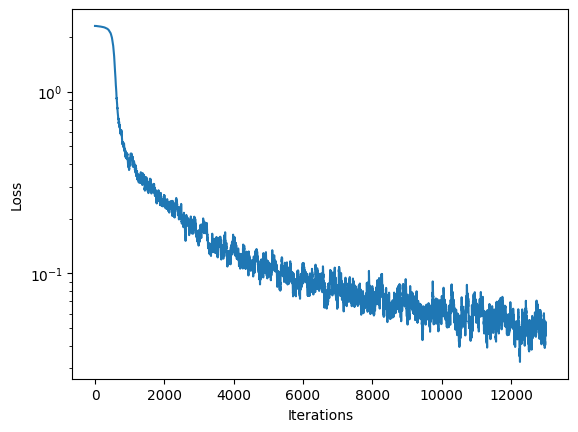

Final Test Accuracy: 0.9838


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : ambitious_damselfly_6848
COMET INFO:     url                   : https://www.comet.com/somil-singh/6-s191lab2-part1-cnn/e020babc12864f13afdaf2094bc65d05
COMET INFO:   Metrics:
COMET INFO:     accuracy : 0.9838
COMET INFO:   Others:
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=1xdnzT9AElOLd2Vc3q9OQSAia7OLaKowb
COMET INFO:   Uploads:
COMET INFO:     environment details : 1
COMET INFO:     filename            : 1
COMET INFO:     installed packages  : 1
COMET INFO:     notebook            : 2
COMET INFO:     os packages         : 1
COMET INFO:     source_code         : 1
COMET INFO: 
COMET WARNING: To get all data logg

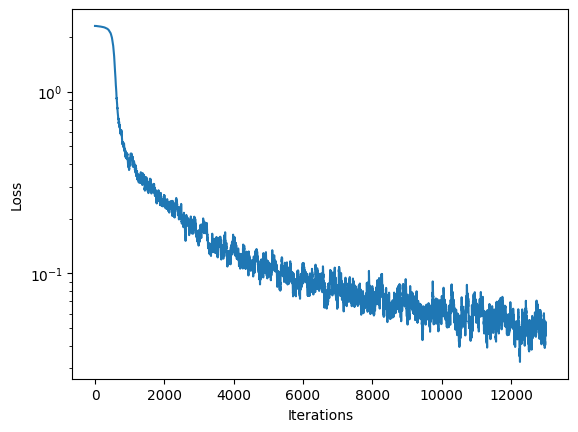

In [18]:
num_batches = len(trainset_loader)

for epoch in range(epochs):
    for batch_idx, (images, labels) in enumerate(trainset_loader):
        # Move to GPU
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = cnn_model(images)

        # Optimizer zero grad
        optimizer.zero_grad()

        # Loss
        loss = loss_function(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Record and plot loss
        loss_history.append(loss.item())
        if batch_idx % 10 == 0:
            plotter.plot(loss_history.get())

# Record the final model metric: accuracy
cnn_model.eval()
correct_pred = 0
total_pred = 0
with torch.no_grad():
    for images, labels in testset_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        predicted = torch.argmax(outputs, dim=1)
        correct_pred += (predicted == labels).sum().item()
        total_pred += labels.size(0)

accuracy = correct_pred / total_pred
print(f"Final Test Accuracy: {accuracy:.4f}")
comet_model_2.log_metric("accuracy", accuracy)
comet_model_2.end()

📝 **My note — what I learned from the shape of the curve:**
Where I actually learned something was in comparing this curve with the baseline's. The CNN sheds most of its loss inside the first epoch and then grinds down against a low floor; the baseline was still descending when its five epochs ran out, still spending early steps relearning that neighbouring pixels are related. One caveat I'll own before anyone reads too much into it: the baseline printed a single loss per epoch while this one is plotted per batch and smoothed at 0.95, so it's a comparison of shapes rather than of matched numbers.

```text
baseline        |    CNN
       \         |        \
        \_____    |         \____
         /    \   |          /    \
        /      \__|         /      \__
          epoch1..5          epoch1..7, batch-level, smoothed 0.95
```

The two curves overlap around the start of training, but the CNN's descent is faster off the line and settles earlier; the flat, shallow improvement of the fully connected model is the part that made the architecture change feel like more than a parameter tweak.

### Make predictions on the test dataset
Now let's evaluate the test accuracy of the CNN model, and make predictions on some of the test images.

In [19]:
# Evaluate the CNN model on the test dataset
test_loss, test_acc_cnn = evaluate(cnn_model, testset_loader, loss_function)
print('Test loss:', test_loss, 'Test accuracy:', test_acc_cnn)

Test loss: 0.053946289389953016 Test accuracy: 0.9838


In [20]:
# Obtain a single batch of test images
images, labels = next(iter(testset_loader))
images = images.to(device)

# Make predictions on the test images
predictions = cnn_model(images)
predictions_test_image = predictions[0]
print(predictions_test_image)

tensor([ -1.9591,  -0.7743,   6.0068,   6.3727,  -5.5479,   0.3537, -14.9762,
         14.7582,   0.4133,   3.5895], device='cuda:0',
       grad_fn=<SelectBackward0>)


With this function call, the model has predicted the label of the first image in the testing set. Let's take a look at the prediction:

As you can see, a prediction is an array of 10 numbers. Recall that the output of our model is a distribution over the 10 digit classes. Thus, these numbers describe the model's predicted likelihood that the image corresponds to each of the 10 different digits.
Let's look at the digit that has the highest likelihood for the first image in the test dataset:

In [21]:
# identify the digit with the highest likelihood prediction for the first
# image in the test dataset.
predictions_value = predictions_test_image.cpu().detach().numpy() #.cpu() to copy tensor to memory first
prediction = np.argmax(predictions_value)
print(prediction)

7


So, the model is most confident that this image is a specific digit. We can check the test label (remember, this is the true identity of the digit) to see if this prediction is correct:

Label of this digit is: 7


/usr/local/lib/python3.13/dist-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  x = np.array(x, subok=True, copy=copy)


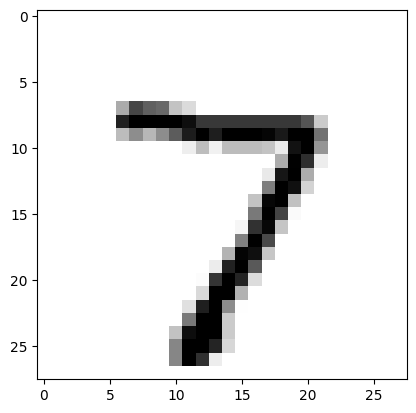

In [22]:
test_image, test_label = test_dataset[0]
print("Label of this digit is:", test_label)
plt.imshow(test_image.squeeze(), cmap=plt.cm.binary)
comet_model_2.log_figure(figure=plt)

📝 **My note — where the CNN still gets it wrong:**
The part of this lab that still felt honest to me was the wrong predictions. Overall accuracy is easy to quote, but it hides the fact that the mistakes cluster on the visually ambiguous digits — 4 vs 9, 3 vs 5 vs 8 — not on random ones. That's worth remembering: a single high-accuracy number can look great while the model is quietly confused on a real subset of the data.

It is! Let's visualize the classification results on the MNIST dataset. We will plot images from the test dataset along with their predicted label, as well as a histogram that provides the prediction probabilities for each of the digits.

Recall that in PyTorch the MNIST dataset is typically accessed using a DataLoader to iterate through the test set in smaller, manageable batches. By appending the predictions, test labels, and test images from each batch, we will first gradually accumulate all the data needed for visualization into singular variables to observe our model's predictions.

In [23]:
# Initialize variables to store all data
all_predictions = []
all_labels = []
all_images = []

# Process test set in batches
with torch.no_grad():
    for images, labels in testset_loader:
        images = images.to(device)
        outputs = cnn_model(images)

        # Apply softmax to get probabilities from the predicted logits
        probabilities = torch.nn.functional.softmax(outputs, dim=1)

        all_predictions.append(probabilities)
        all_labels.append(labels)
        all_images.append(images)

all_predictions = torch.cat(all_predictions)  # Shape: (total_samples, num_classes)
all_labels = torch.cat(all_labels)            # Shape: (total_samples,)
all_images = torch.cat(all_images)            # Shape: (total_samples, 1, 28, 28)

# Convert tensors to NumPy for compatibility with plotting functions
predictions = all_predictions.cpu().numpy()  # Shape: (total_samples, num_classes)
test_labels = all_labels.numpy()             # Shape: (total_samples,)
test_images = all_images.cpu().numpy()       # Shape: (total_samples, 1, 28, 28)

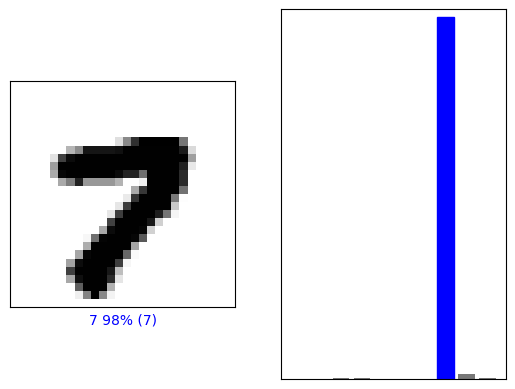

In [24]:
#@title Change the slider to look at the model's predictions! { run: "auto" }

image_index = 79 #@param {type:"slider", min:0, max:100, step:1}
plt.subplot(1,2,1)
mdl.lab2.plot_image_prediction(image_index, predictions, test_labels, test_images)
plt.subplot(1,2,2)
mdl.lab2.plot_value_prediction(image_index, predictions, test_labels)
comet_model_2.log_figure(figure=plt)

We can also plot several images along with their predictions, where correct prediction labels are blue and incorrect prediction labels are grey. The number gives the percent confidence (out of 100) for the predicted label. Note the model can be very confident in an incorrect prediction!

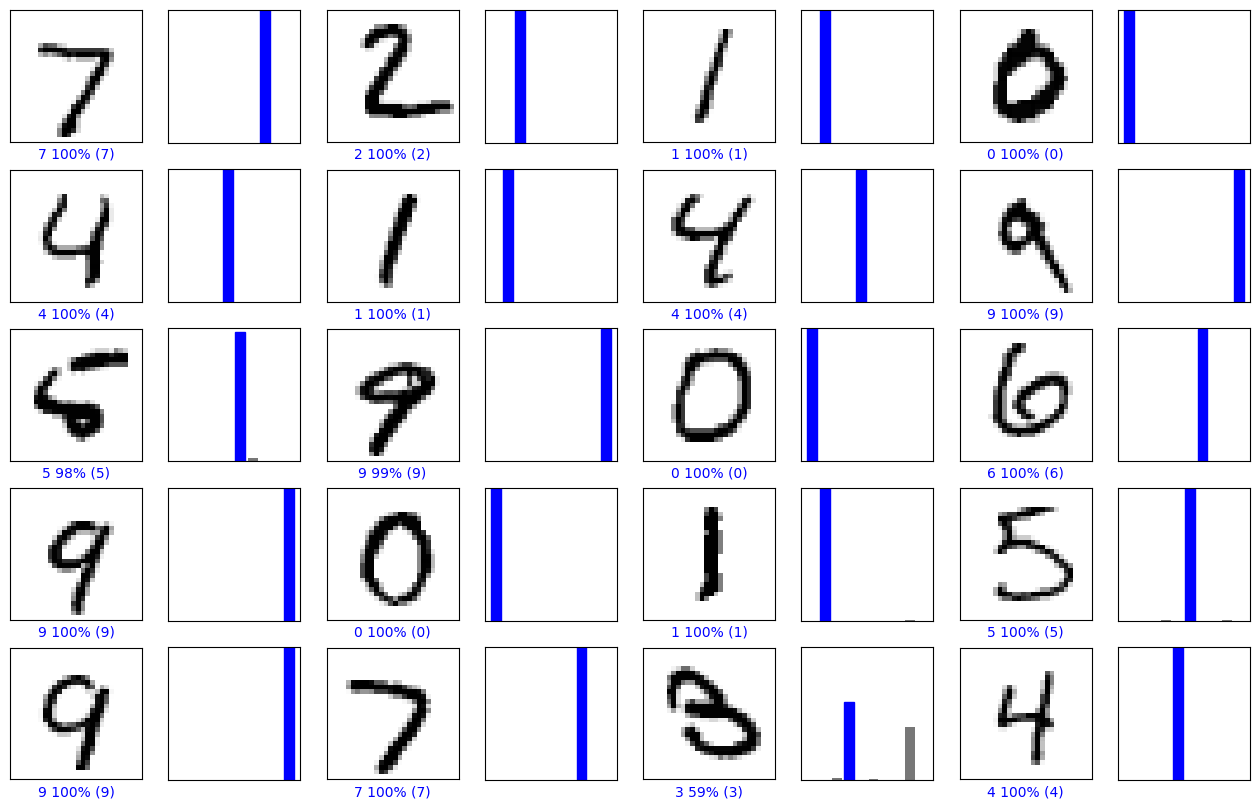

In [25]:
# Plots the first X test images, their predicted label, and the true label
# Color correct predictions in blue, incorrect predictions in red
num_rows = 5
num_cols = 4
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    mdl.lab2.plot_image_prediction(i, predictions, test_labels, test_images)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    mdl.lab2.plot_value_prediction(i, predictions, test_labels)
comet_model_2.log_figure(figure=plt)
comet_model_2.end()

### 1.5 Conclusion
In this part of the lab, you had the chance to play with different MNIST classifiers with different architectures (fully-connected layers only, CNN), and experiment with how different hyperparameters affect accuracy (learning rate, etc.). The next part of the lab explores another application of CNNs, facial detection, and some drawbacks of AI systems in real world applications, like issues of bias.